# Semana 11: Redes neuronales convolucionales (CNNs)
## Fundamentos de IA y Machine Learning | ULACIT | 92-0025
---

En este notebook vamos a **aprender haciendo**. En lugar de una presentacion teorica tradicional, vamos a construir, entrenar y analizar una red neuronal convolucional paso a paso.

Al finalizar, usted sera capaz de:
- Explicar que es una convolucion y por que es util para procesar imagenes
- Describir la arquitectura de una CNN (capas convolucionales, pooling, fully connected)
- Entrenar una CNN con datos reales y evaluar su rendimiento
- Visualizar como la red "ve" las imagenes en cada capa
- Conectar estos conceptos con aplicaciones empresariales reales en 2025-2026

> **Nota importante:** No necesita ser programador para seguir este notebook. El codigo esta escrito y documentado para que usted lo ejecute celda por celda y observe los resultados. Lo importante es entender **que hace** cada paso y **por que** es relevante para decisiones de negocio.

## 0. Configuracion del entorno

Primero verificamos que estamos usando GPU (mucho mas rapido para entrenar CNNs) e importamos las librerias necesarias.

> **Para activar GPU en Colab:** Menu > Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU T4

In [2]:
# Verificar si hay GPU disponible
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")
if tf.config.list_physical_devices('GPU'):
    print("Excelente! Estamos usando GPU, el entrenamiento sera mucho mas rapido.")
else:
    print("No hay GPU. El notebook funcionara, pero el entrenamiento sera mas lento.")
    print("Recomendacion: Menu > Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU T4")

TensorFlow version: 2.21.0
GPU disponible: []
No hay GPU. El notebook funcionara, pero el entrenamiento sera mas lento.
Recomendacion: Menu > Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU T4


In [3]:
# Importar librerias
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Estilo de graficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Colores ULACIT
PURPLE = '#2D1B4E'
CYAN = '#00D4FF'

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


---
## 1. El problema de negocio: clasificacion automatica de productos

Imaginemos que trabajamos en el equipo de tecnologia de una empresa de comercio electronico en Costa Rica. La empresa recibe **miles de fotografias de productos** diariamente de vendedores que publican articulos en la plataforma.

**El problema:** Actualmente, un equipo de 8 personas clasifica manualmente cada imagen en su categoria correcta (camisetas, pantalones, zapatos, bolsos, etc.). Esto es lento, costoso y propenso a errores.

**La pregunta de negocio:** Puede una red neuronal convolucional clasificar automaticamente imagenes de productos con suficiente precision como para reemplazar o asistir al equipo humano?

Para explorar esta pregunta, usaremos **Fashion-MNIST**, un dataset de referencia con 70,000 imagenes de articulos de moda en 10 categorias. Cada imagen tiene 28x28 pixeles en escala de grises.

In [4]:
# Cargar el dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Nombres de las 10 categorias de productos
nombres_categorias = [
    'Camiseta/Top', 'Pantalon', 'Sueter', 'Vestido', 'Abrigo',
    'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota'
]

print(f"Imagenes de entrenamiento: {X_train.shape[0]:,}")
print(f"Imagenes de prueba: {X_test.shape[0]:,}")
print(f"Tamano de cada imagen: {X_train.shape[1]}x{X_train.shape[2]} pixeles")
print(f"Categorias: {len(nombres_categorias)}")
print(f"\nCategorias disponibles:")
for i, nombre in enumerate(nombres_categorias):
    count = np.sum(y_train == i)
    print(f"  {i}: {nombre} ({count:,} imagenes)")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 7us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Imagenes de entrenamiento: 60,000
Imagenes de prueba: 10,000
Tamano de cada imagen: 28x28 pixeles
Categorias: 10

Categorias disponibles:
  0: Camiseta/Top (6,000 imagenes)
  1: Pantalon (6,000 imagenes)
  2: Sueter (6,000 imagenes)
  3: Vestido (6,000 imagenes)
  4: Abrigo (6,000 imagenes)
  5: Sandalia (6,000 imagenes)
  6: Camisa (6,000 imagenes)
  7: Zapatilla (6,000 imagenes)
  8: Bolso (6,000 imagenes)
  9: Bota (6,000 imagenes)


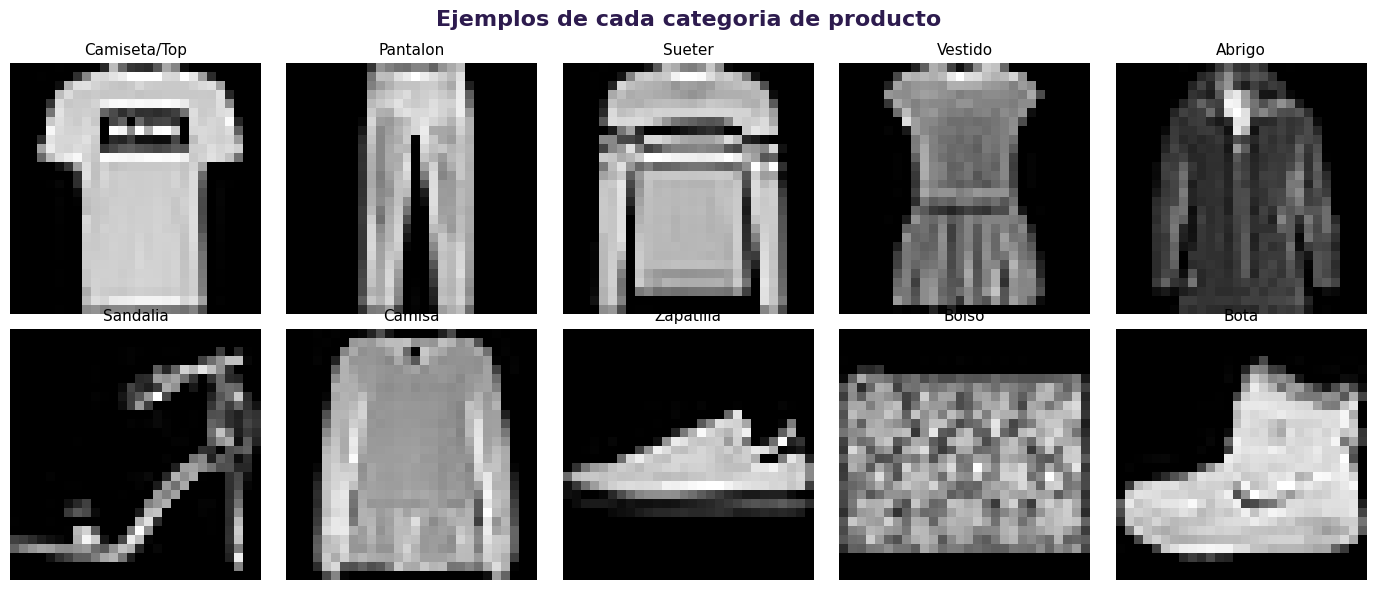


Cada imagen es una cuadricula de 28x28 = 784 pixeles.
Cada pixel tiene un valor entre 0 (negro) y 255 (blanco).
Nuestro objetivo: que la CNN aprenda a distinguir estas 10 categorias automaticamente.


In [5]:
# Visualizar ejemplos del dataset
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Ejemplos de cada categoria de producto', fontsize=16, fontweight='bold', color=PURPLE)

for i in range(10):
    ax = axes[i // 5, i % 5]
    # Encontrar un ejemplo de la categoria i
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(nombres_categorias[i], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nCada imagen es una cuadricula de 28x28 = 784 pixeles.")
print("Cada pixel tiene un valor entre 0 (negro) y 255 (blanco).")
print("Nuestro objetivo: que la CNN aprenda a distinguir estas 10 categorias automaticamente.")

---
## 2. Que es una convolucion (y por que es revolucionaria)

### La idea central

Una **convolucion** es una operacion matematica que desliza un pequeno filtro (por ejemplo, de 3x3 pixeles) sobre una imagen. En cada posicion, multiplica los valores del filtro por los pixeles correspondientes y suma el resultado. Esto produce un nuevo valor que captura si el patron del filtro esta presente en esa region.

### Analogia empresarial

Imaginen que tienen un equipo de inspectores de calidad en una fabrica:
- **Inspector 1:** Solo busca bordes verticales en el producto
- **Inspector 2:** Solo busca bordes horizontales
- **Inspector 3:** Solo busca esquinas
- **Inspector 4:** Solo busca texturas especificas

Cada inspector (filtro) revisa **toda** la imagen, pero solo reporta si encontro **su** patron especifico. El resultado es un "mapa" de donde se encontro cada patron. Eso es exactamente lo que hace una capa convolucional.

Veamos esto en accion con codigo:

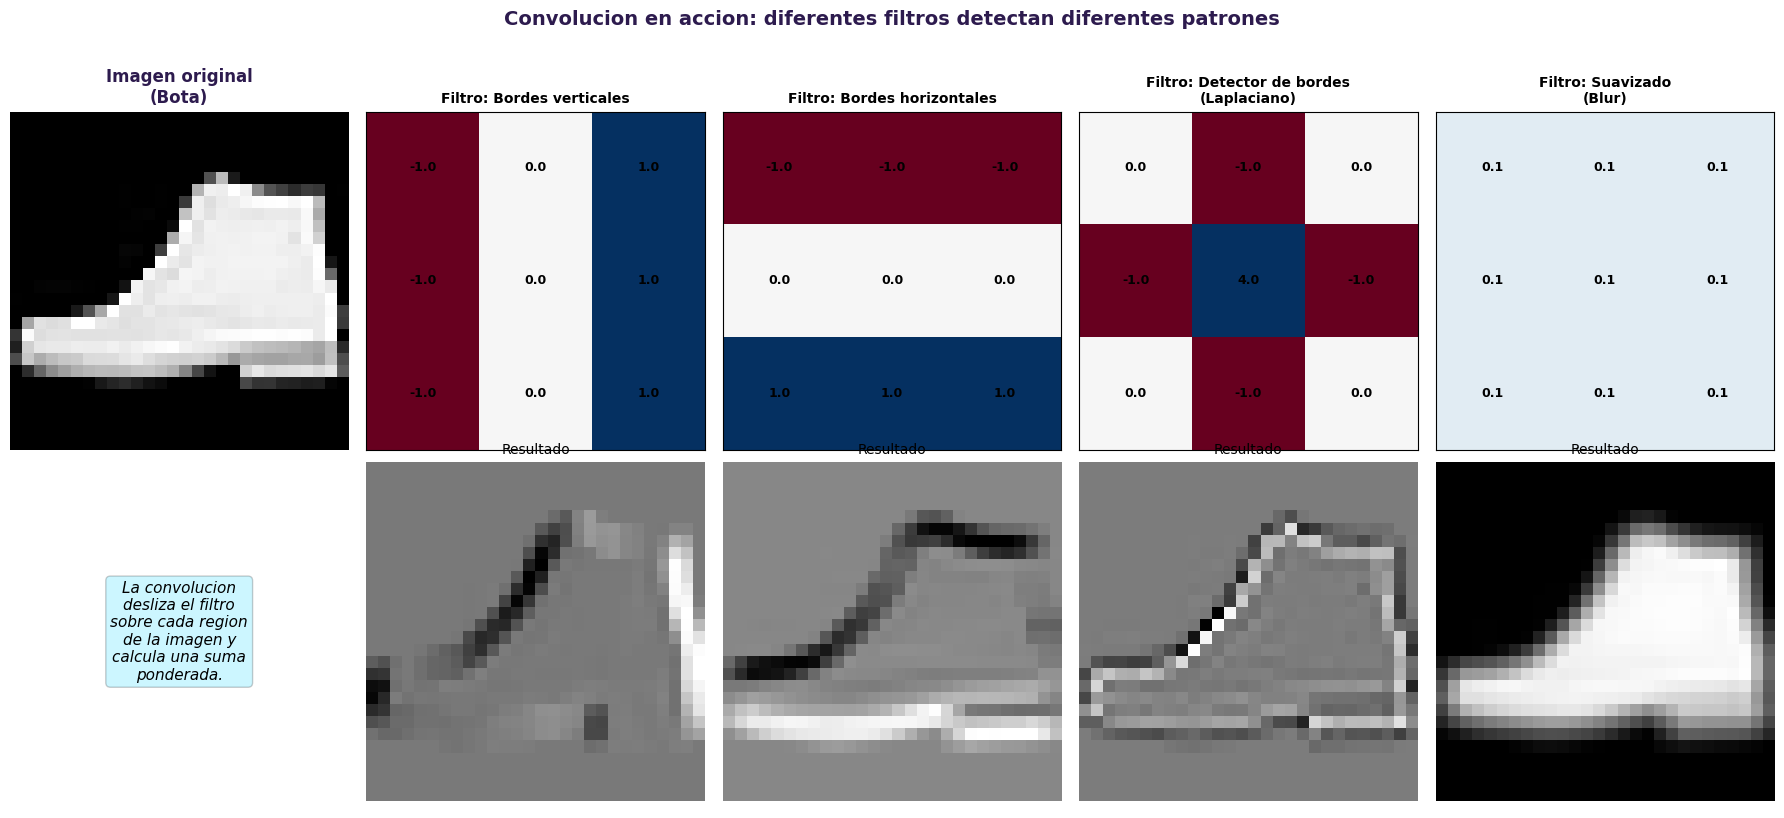

Observaciones clave:
  - El filtro de bordes verticales resalta las lineas verticales de la bota
  - El filtro de bordes horizontales resalta la suela y la parte superior
  - El Laplaciano detecta todos los bordes (contornos del objeto)
  - El suavizado difumina la imagen (reduce ruido)

En una CNN, la red APRENDE automaticamente cuales filtros son los mas utiles!


In [6]:
from scipy import signal

# Tomemos una imagen de ejemplo: una bota
ejemplo_idx = np.where(y_train == 9)[0][3]  # Una bota
imagen_ejemplo = X_train[ejemplo_idx].astype(float)

# Definir filtros clasicos (estos son los "inspectores" de nuestra analogia)
filtros = {
    'Bordes verticales': np.array([[-1, 0, 1],
                                   [-1, 0, 1],
                                   [-1, 0, 1]]),

    'Bordes horizontales': np.array([[-1, -1, -1],
                                     [ 0,  0,  0],
                                     [ 1,  1,  1]]),

    'Detector de bordes\n(Laplaciano)': np.array([[ 0, -1,  0],
                                                   [-1,  4, -1],
                                                   [ 0, -1,  0]]),

    'Suavizado\n(Blur)': np.array([[1, 1, 1],
                                    [1, 1, 1],
                                    [1, 1, 1]]) / 9.0
}

# Aplicar cada filtro a la imagen
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Imagen original
axes[0, 0].imshow(imagen_ejemplo, cmap='gray')
axes[0, 0].set_title('Imagen original\n(Bota)', fontsize=12, fontweight='bold', color=PURPLE)
axes[0, 0].axis('off')

# Resultados de cada filtro
for i, (nombre, filtro) in enumerate(filtros.items()):
    resultado = signal.convolve2d(imagen_ejemplo, filtro, mode='same')

    # Mostrar el filtro (arriba)
    axes[0, i+1].imshow(filtro, cmap='RdBu', vmin=-1, vmax=1)
    axes[0, i+1].set_title(f'Filtro: {nombre}', fontsize=10, fontweight='bold')
    for y in range(3):
        for x in range(3):
            axes[0, i+1].text(x, y, f'{filtro[y,x]:.1f}', ha='center', va='center',
                             fontsize=9, color='black', fontweight='bold')
    axes[0, i+1].set_xticks([])
    axes[0, i+1].set_yticks([])

    # Mostrar el resultado (abajo)
    axes[1, i+1].imshow(resultado, cmap='gray')
    axes[1, i+1].set_title(f'Resultado', fontsize=10)
    axes[1, i+1].axis('off')

axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'La convolucion\ndesliza el filtro\nsobre cada region\nde la imagen y\ncalcula una suma\nponderada.',
                ha='center', va='center', fontsize=11, style='italic',
                transform=axes[1,0].transAxes,
                bbox=dict(boxstyle='round', facecolor=CYAN, alpha=0.2))

fig.suptitle('Convolucion en accion: diferentes filtros detectan diferentes patrones',
             fontsize=14, fontweight='bold', color=PURPLE, y=1.02)
plt.tight_layout()
plt.show()

print("Observaciones clave:")
print("  - El filtro de bordes verticales resalta las lineas verticales de la bota")
print("  - El filtro de bordes horizontales resalta la suela y la parte superior")
print("  - El Laplaciano detecta todos los bordes (contornos del objeto)")
print("  - El suavizado difumina la imagen (reduce ruido)")
print("\nEn una CNN, la red APRENDE automaticamente cuales filtros son los mas utiles!")

### Punto clave para el negocio

Los filtros que acabamos de ver fueron disenados manualmente por humanos. La magia de las CNNs es que **aprenden automaticamente** que filtros necesitan. Durante el entrenamiento, la red descubre por si misma que patrones son importantes para distinguir una camiseta de un pantalon, o un grano de cafe sano de uno defectuoso.

Esto significa que usted **no necesita ser experto en vision** para usar CNNs. Solo necesita datos etiquetados (imagenes con su categoria correcta) y la red aprende sola.

---
## 3. Arquitectura de una CNN: las tres piezas fundamentales

Una CNN tipica tiene tres tipos de capas, cada una con un rol especifico:

| Capa | Que hace | Analogia de negocio |
|------|----------|--------------------|
| **Convolucional** | Aplica filtros para detectar patrones (bordes, texturas, formas) | Inspectores especializados que buscan caracteristicas especificas |
| **Pooling** | Reduce el tamano de los mapas de caracteristicas, conservando lo importante | Resumen ejecutivo: quedarse con lo esencial, descartar detalles menores |
| **Fully Connected** | Combina todas las caracteristicas extraidas para tomar una decision final | Comite directivo que recibe los reportes de todos los inspectores y toma la decision |

### Flujo de procesamiento:
```
Imagen de entrada (28x28)
    --> Capa convolucional 1 (detecta bordes simples)
    --> Pooling 1 (reduce tamano)
    --> Capa convolucional 2 (detecta formas complejas)
    --> Pooling 2 (reduce tamano)
    --> Aplanar (convertir mapa 2D a vector 1D)
    --> Capa fully connected (combinar todo)
    --> Salida: 10 probabilidades (una por categoria)
```

Vamos a construir exactamente esta arquitectura:

In [7]:
# Preparar los datos
# 1. Normalizar pixeles de [0, 255] a [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# 2. Agregar dimension de canal (las CNNs esperan formato: alto x ancho x canales)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print(f"Forma de los datos de entrenamiento: {X_train_cnn.shape}")
print(f"  - {X_train_cnn.shape[0]:,} imagenes")
print(f"  - {X_train_cnn.shape[1]}x{X_train_cnn.shape[2]} pixeles")
print(f"  - {X_train_cnn.shape[3]} canal (escala de grises)")
print(f"\nValores de pixeles ahora van de {X_train_cnn.min():.1f} a {X_train_cnn.max():.1f}")
print("(Normalizar ayuda a que la red aprenda mas rapido y de manera mas estable)")

Forma de los datos de entrenamiento: (60000, 28, 28, 1)
  - 60,000 imagenes
  - 28x28 pixeles
  - 1 canal (escala de grises)

Valores de pixeles ahora van de 0.0 a 1.0
(Normalizar ayuda a que la red aprenda mas rapido y de manera mas estable)


In [8]:
# Construir la CNN
modelo_cnn = models.Sequential([
    # === BLOQUE 1: Primer nivel de extraccion de caracteristicas ===
    # Capa convolucional: 32 filtros de 3x3
    # Cada filtro aprende a detectar un patron diferente
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1),
                  name='conv1_detectar_bordes'),

    # Max Pooling: reduce cada mapa de 26x26 a 13x13
    # Se queda con el valor maximo en cada ventana de 2x2
    layers.MaxPooling2D((2, 2), name='pool1_resumen'),

    # === BLOQUE 2: Segundo nivel (patrones mas complejos) ===
    # 64 filtros que combinan los patrones simples del bloque 1
    layers.Conv2D(64, (3, 3), activation='relu',
                  name='conv2_detectar_formas'),

    layers.MaxPooling2D((2, 2), name='pool2_resumen'),

    # === BLOQUE 3: Tercer nivel (patrones de alto nivel) ===
    layers.Conv2D(64, (3, 3), activation='relu',
                  name='conv3_detectar_objetos'),

    # === CLASIFICADOR: Tomar la decision final ===
    # Aplanar los mapas 2D en un vector 1D
    layers.Flatten(name='aplanar'),

    # Capa densa (fully connected) para combinar toda la informacion
    layers.Dense(64, activation='relu', name='combinar_informacion'),

    # Capa de salida: 10 neuronas (una por categoria), softmax da probabilidades
    layers.Dense(10, activation='softmax', name='decision_final')
])

# Ver la arquitectura completa
modelo_cnn.summary()

print("\n" + "="*60)
print("INTERPRETACION PARA NEGOCIOS:")
print("="*60)
total_params = modelo_cnn.count_params()
print(f"Total de parametros: {total_params:,}")
print(f"Estos son los 'conocimientos' que la red debe aprender.")
print(f"Comparemos con una red densa tradicional:")
params_densa = 28*28*128 + 128*64 + 64*10
print(f"  Red densa equivalente: ~{params_densa:,} parametros")
print(f"  Nuestra CNN: {total_params:,} parametros")
print(f"  La CNN es mas eficiente porque REUTILIZA los mismos filtros")
print(f"  en toda la imagen (comparticion de parametros).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_detectar_bordes (Conv2D)  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_resumen (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_detectar_formas (Conv2D)  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2_resumen (MaxPooling2D)    │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_detectar_objetos (Conv2D) │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aplanar (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ combinar_informacion (Dense)    │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decision_final (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)


INTERPRETACION PARA NEGOCIOS:
Total de parametros: 93,322
Estos son los 'conocimientos' que la red debe aprender.
Comparemos con una red densa tradicional:
  Red densa equivalente: ~109,184 parametros
  Nuestra CNN: 93,322 parametros
  La CNN es mas eficiente porque REUTILIZA los mismos filtros
  en toda la imagen (comparticion de parametros).


### Entendiendo la tabla de arquitectura

Observen el resumen anterior:

1. **conv1** produce 32 mapas de caracteristicas de 26x26 (la imagen se reduce un poco porque el filtro 3x3 no cabe en los bordes exactos)
2. **pool1** reduce cada mapa a 13x13 ("resumen ejecutivo")
3. **conv2** produce 64 mapas de 11x11 (combina patrones del nivel anterior)
4. **pool2** reduce a 5x5
5. **conv3** produce 64 mapas de 3x3
6. **aplanar** convierte los 64 mapas de 3x3 = 576 valores en un vector
7. **combinar** procesa los 576 valores con 64 neuronas
8. **decision** las 10 neuronas finales dan la probabilidad de cada categoria

La clave: cada capa convolucional ve patrones **mas abstractos y complejos** que la anterior.

---
## 4. Entrenamiento: la CNN aprende de los datos

Ahora entrenamos la red. Esto significa mostrarle las 60,000 imagenes de entrenamiento repetidamente (cada repeticion completa se llama una **epoca**) para que ajuste sus filtros y pesos.

Es como entrenar a nuestro equipo de inspectores: los exponemos a miles de ejemplos para que aprendan a reconocer cada tipo de producto.

In [10]:
# Compilar el modelo
modelo_cnn.compile(
    optimizer='adam',                        # Algoritmo de optimizacion
    loss='sparse_categorical_crossentropy',  # Funcion de perdida para clasificacion
    metrics=['accuracy']                     # Metrica que nos importa: precision
)

print("Entrenando la CNN... (esto toma 1-2 minutos con GPU)\n")

# Entrenar durante 10 epocas
historial = modelo_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,  # 10% de datos para validacion
    verbose=1
)

print("\nEntrenamiento completado!")

Entrenando la CNN... (esto toma 1-2 minutos con GPU)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9441 - loss: 0.1487 - val_accuracy: 0.9115 - val_loss: 0.2683
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9491 - loss: 0.1373 - val_accuracy: 0.9022 - val_loss: 0.2820
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9528 - loss: 0.1261 - val_accuracy: 0.9095 - val_loss: 0.2780
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9573 - loss: 0.1155 - val_accuracy: 0.9118 - val_loss: 0.3013
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9611 - loss: 0.1044 - val_accuracy: 0.9090 - val_loss: 0.2918
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9631 - loss: 0.0980 - val_accuracy: 0.9132 - val_loss: 0.3034
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9661 - loss: 0.0893 - val_accuracy: 0.9117 - val_loss: 0.3360
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s

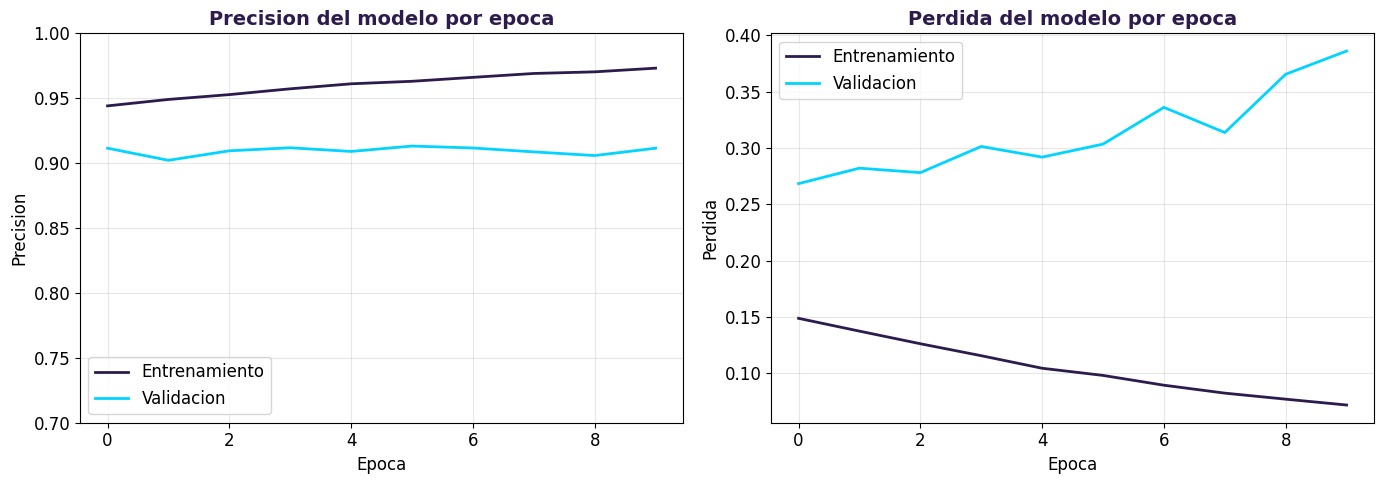

Interpretacion:
  - La precision sube rapidamente en las primeras epocas (la red aprende los patrones obvios)
  - Luego se estabiliza (rendimientos decrecientes, como en muchos procesos de negocio)
  - Si la linea de validacion se aleja mucho de la de entrenamiento = overfitting
    (la red memoriza ejemplos en vez de aprender patrones generales)


In [12]:
# Visualizar el proceso de aprendizaje
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision
ax1.plot(historial.history['accuracy'], color=PURPLE, linewidth=2, label='Entrenamiento')
ax1.plot(historial.history['val_accuracy'], color=CYAN, linewidth=2, label='Validacion')
ax1.set_title('Precision del modelo por epoca', fontsize=14, fontweight='bold', color=PURPLE)
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Precision')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.7, 1.0])

# Perdida
ax2.plot(historial.history['loss'], color=PURPLE, linewidth=2, label='Entrenamiento')
ax2.plot(historial.history['val_loss'], color=CYAN, linewidth=2, label='Validacion')
ax2.set_title('Perdida del modelo por epoca', fontsize=14, fontweight='bold', color=PURPLE)
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Perdida')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretacion:")
print("  - La precision sube rapidamente en las primeras epocas (la red aprende los patrones obvios)")
print("  - Luego se estabiliza (rendimientos decrecientes, como en muchos procesos de negocio)")
print("  - Si la linea de validacion se aleja mucho de la de entrenamiento = overfitting")
print("    (la red memoriza ejemplos en vez de aprender patrones generales)")

In [13]:
# Evaluar en datos de prueba (datos que la red NUNCA ha visto)
perdida_test, precision_test = modelo_cnn.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Resultado en datos de prueba:")
print(f"  Precision: {precision_test:.1%}")
print(f"  Perdida: {perdida_test:.4f}")
print(f"\nEsto significa que la CNN clasifica correctamente ~{precision_test:.0%} de los productos.")
print(f"Para un catalogo con 10,000 productos, erraria en aproximadamente {int(10000*(1-precision_test)):,}.")

Resultado en datos de prueba:
  Precision: 91.2%
  Perdida: 0.3828

Esto significa que la CNN clasifica correctamente ~91% de los productos.
Para un catalogo con 10,000 productos, erraria en aproximadamente 881.


---
## 5. Analisis de errores: donde falla la CNN y por que importa

En un contexto de negocio, no basta con saber la precision general. Necesitamos entender:
- Cuales categorias se confunden mas?
- Que tipo de errores son mas costosos?
- Donde necesitamos intervencion humana?

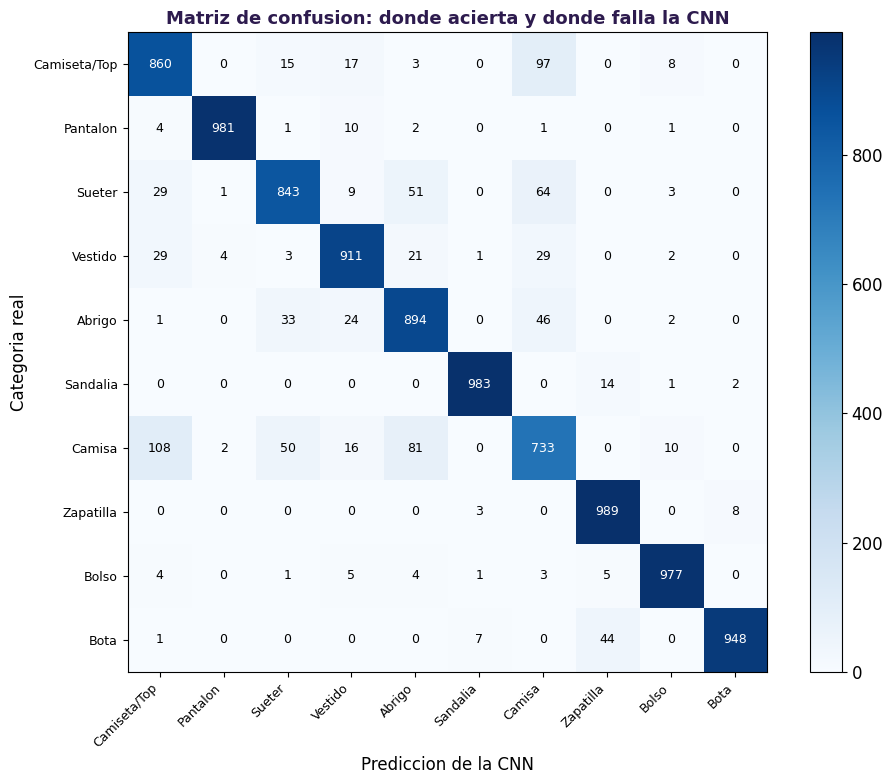

Observaciones clave:
  - Los valores altos en la diagonal = clasificaciones correctas
  - Los valores fuera de la diagonal = errores
  - Busque las confusiones mas frecuentes entre categorias similares
    (por ejemplo, Camiseta vs Camisa, o Sueter vs Abrigo)


In [14]:
# Generar predicciones
predicciones = modelo_cnn.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(predicciones, axis=1)

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Matriz de confusion: donde acierta y donde falla la CNN',
             fontsize=13, fontweight='bold', color=PURPLE)

# Agregar numeros en cada celda
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                color=color, fontsize=9)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(nombres_categorias, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(nombres_categorias, fontsize=9)
ax.set_xlabel('Prediccion de la CNN', fontsize=12)
ax.set_ylabel('Categoria real', fontsize=12)
plt.colorbar(im)
plt.tight_layout()
plt.show()

print("Observaciones clave:")
print("  - Los valores altos en la diagonal = clasificaciones correctas")
print("  - Los valores fuera de la diagonal = errores")
print("  - Busque las confusiones mas frecuentes entre categorias similares")
print("    (por ejemplo, Camiseta vs Camisa, o Sueter vs Abrigo)")

In [15]:
# Reporte detallado por categoria
print("Reporte de clasificacion por categoria:")
print("="*70)
reporte = classification_report(y_test, y_pred, target_names=nombres_categorias)
print(reporte)

print("Interpretacion para el negocio:")
print("  - Precision: de los productos que la CNN dice que son X, cuantos realmente lo son?")
print("  - Recall: de todos los productos que realmente son X, cuantos detecta la CNN?")
print("  - F1-score: balance entre precision y recall")
print("\n  Las categorias con F1-score bajo son candidatas para revision humana adicional.")

Reporte de clasificacion por categoria:
              precision    recall  f1-score   support

Camiseta/Top       0.83      0.86      0.84      1000
    Pantalon       0.99      0.98      0.99      1000
      Sueter       0.89      0.84      0.87      1000
     Vestido       0.92      0.91      0.91      1000
      Abrigo       0.85      0.89      0.87      1000
    Sandalia       0.99      0.98      0.99      1000
      Camisa       0.75      0.73      0.74      1000
   Zapatilla       0.94      0.99      0.96      1000
       Bolso       0.97      0.98      0.98      1000
        Bota       0.99      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Interpretacion para el negocio:
  - Precision: de los productos que la CNN dice que son X, cuantos realmente lo son?
  - Recall: de todos los productos que realmente son X, cuantos detecta la CNN?
  - 

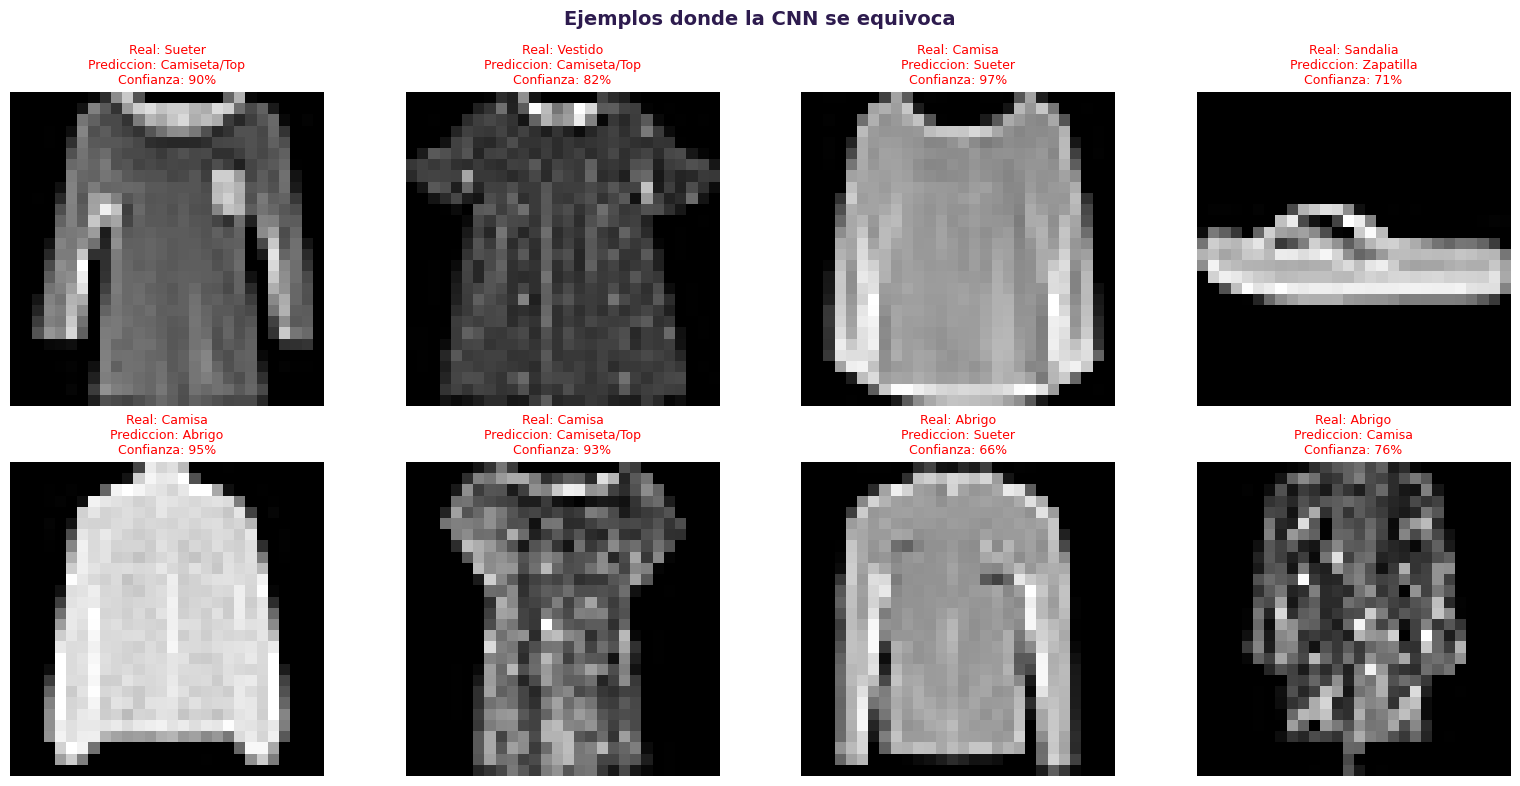


Total de errores: 881 de 10,000 imagenes
Tasa de error: 8.8%

Nota: muchos errores ocurren en imagenes ambiguas incluso para humanos.


In [16]:
# Visualizar ejemplos de errores (importante para entender las limitaciones)
errores = np.where(y_pred != y_test)[0]
np.random.seed(42)
errores_muestra = np.random.choice(errores, size=min(8, len(errores)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Ejemplos donde la CNN se equivoca', fontsize=14, fontweight='bold', color=PURPLE)

for i, idx in enumerate(errores_muestra):
    ax = axes[i // 4, i % 4]
    ax.imshow(X_test[idx], cmap='gray')
    prob_max = predicciones[idx][y_pred[idx]] * 100
    ax.set_title(f'Real: {nombres_categorias[y_test[idx]]}\n'
                 f'Prediccion: {nombres_categorias[y_pred[idx]]}\n'
                 f'Confianza: {prob_max:.0f}%',
                 fontsize=9, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nTotal de errores: {len(errores):,} de {len(y_test):,} imagenes")
print(f"Tasa de error: {len(errores)/len(y_test):.1%}")
print(f"\nNota: muchos errores ocurren en imagenes ambiguas incluso para humanos.")

---
## 6. Visualizacion: como "ve" la CNN las imagenes

Esta es una de las partes mas fascinantes y relevantes para el negocio. La **explicabilidad** de la IA es cada vez mas importante: reguladores, clientes y directivos quieren saber **por que** la IA tomo una decision.

Vamos a visualizar los filtros aprendidos y los mapas de activacion (lo que la CNN "ve" en cada capa).

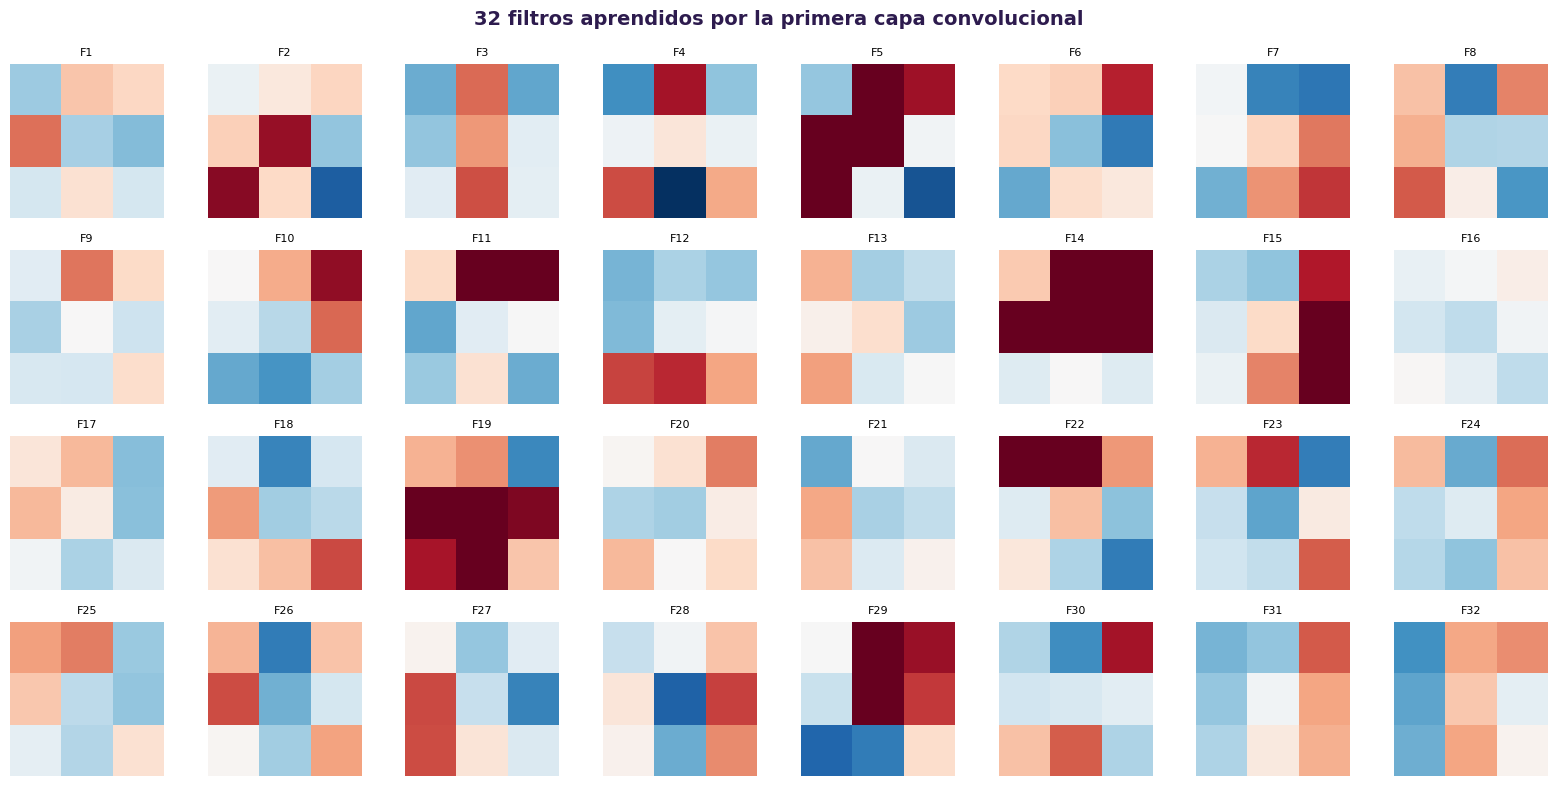

Cada pequeno cuadro es un filtro de 3x3 que la CNN aprendio automaticamente.
Los colores rojo/azul representan valores positivos/negativos.
Algunos detectan bordes verticales, otros horizontales, diagonales, etc.

Punto clave: nadie programo estos filtros. La red los descubrio sola
a partir de los datos de entrenamiento.


In [17]:
# Visualizar los filtros aprendidos por la primera capa convolucional
filtros_aprendidos = modelo_cnn.layers[0].get_weights()[0]  # Forma: (3, 3, 1, 32)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('32 filtros aprendidos por la primera capa convolucional',
             fontsize=14, fontweight='bold', color=PURPLE)

for i in range(32):
    ax = axes[i // 8, i % 8]
    filtro = filtros_aprendidos[:, :, 0, i]
    ax.imshow(filtro, cmap='RdBu', vmin=-filtros_aprendidos.max(), vmax=filtros_aprendidos.max())
    ax.set_title(f'F{i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Cada pequeno cuadro es un filtro de 3x3 que la CNN aprendio automaticamente.")
print("Los colores rojo/azul representan valores positivos/negativos.")
print("Algunos detectan bordes verticales, otros horizontales, diagonales, etc.")
print("\nPunto clave: nadie programo estos filtros. La red los descubrio sola")
print("a partir de los datos de entrenamiento.")

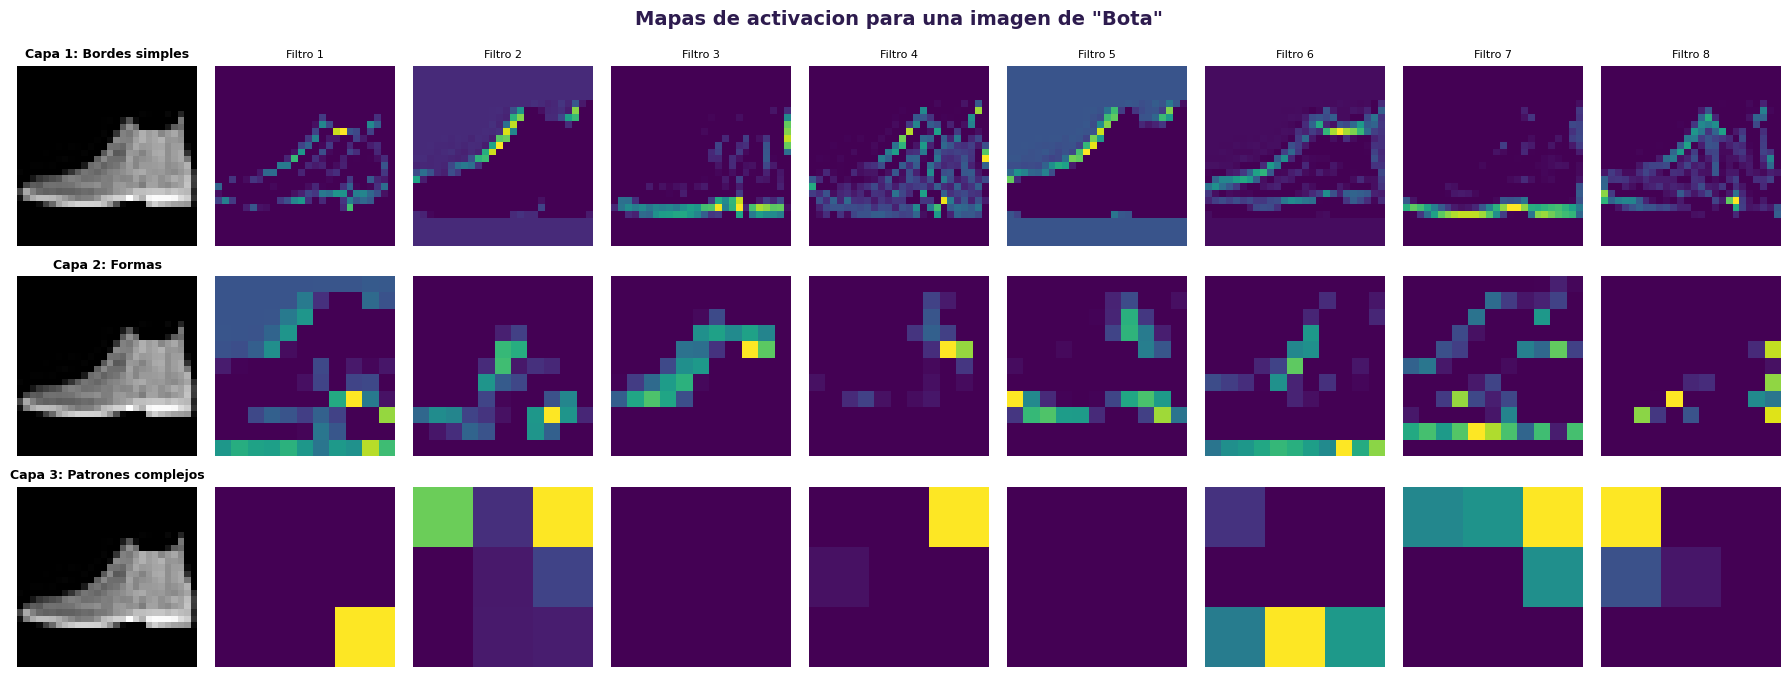

Observe la jerarquia de abstraccion:
  Capa 1: Detecta bordes y texturas basicas (patrones simples)
  Capa 2: Combina bordes en formas (mangas, cuellos, suelas)
  Capa 3: Reconoce partes completas del objeto

Esta jerarquia es similar a como procesamos informacion en una empresa:
  Datos crudos -> Indicadores -> Insights -> Decisiones estrategicas


In [18]:
# Visualizar mapas de activacion: que "ve" la CNN en cada capa
# Extraer activaciones pasando la imagen capa por capa
# (compatible con Keras 3 / TensorFlow 2.16+)

img_test = X_test_cnn[0:1]  # Primera imagen de prueba
categoria_real = nombres_categorias[y_test[0]]

# Pasar la imagen por cada capa y guardar las salidas de las convolucionales
activaciones = []
x = img_test
for layer in modelo_cnn.layers:
    x = layer(x)
    if 'conv' in layer.name:
        activaciones.append(x.numpy())

# Visualizar
nombres_capas = ['Capa 1: Bordes simples', 'Capa 2: Formas', 'Capa 3: Patrones complejos']

fig, axes = plt.subplots(3, 9, figsize=(18, 7))
fig.suptitle(f'Mapas de activacion para una imagen de \"{categoria_real}\"',
             fontsize=14, fontweight='bold', color=PURPLE)

for capa_idx in range(3):
    # Imagen original en la primera columna de cada fila
    axes[capa_idx, 0].imshow(X_test[0], cmap='gray')
    axes[capa_idx, 0].set_title(nombres_capas[capa_idx] if True else '', fontsize=9, fontweight='bold')
    axes[capa_idx, 0].axis('off')

    # Mapas de activacion (8 filtros por capa)
    act = activaciones[capa_idx][0]
    for filtro_idx in range(8):
        col = filtro_idx + 1
        if filtro_idx < act.shape[-1]:
            axes[capa_idx, col].imshow(act[:, :, filtro_idx], cmap='viridis')
        axes[capa_idx, col].axis('off')
        if capa_idx == 0:
            axes[capa_idx, col].set_title(f'Filtro {filtro_idx+1}', fontsize=8)

plt.tight_layout()
plt.show()

print("Observe la jerarquia de abstraccion:")
print("  Capa 1: Detecta bordes y texturas basicas (patrones simples)")
print("  Capa 2: Combina bordes en formas (mangas, cuellos, suelas)")
print("  Capa 3: Reconoce partes completas del objeto")
print("\nEsta jerarquia es similar a como procesamos informacion en una empresa:")
print("  Datos crudos -> Indicadores -> Insights -> Decisiones estrategicas")

---
## 7. Comparacion: CNN vs Red densa (MLP) tradicional

Para apreciar por que las CNNs son superiores para imagenes, entrenemos una red densa tradicional con los mismos datos y comparemos.

In [19]:
# Red densa tradicional (MLP)
modelo_mlp = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1), name='aplanar_imagen'),
    layers.Dense(128, activation='relu', name='capa_oculta_1'),
    layers.Dense(64, activation='relu', name='capa_oculta_2'),
    layers.Dense(10, activation='softmax', name='salida')
])

modelo_mlp.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("Entrenando red densa tradicional (MLP) para comparar...\n")
hist_mlp = modelo_mlp.fit(X_train_cnn, y_train, epochs=10, batch_size=64,
                          validation_split=0.1, verbose=1)

_, precision_mlp = modelo_mlp.evaluate(X_test_cnn, y_test, verbose=0)

print(f"\n{'='*50}")
print(f"COMPARACION DE RESULTADOS")
print(f"{'='*50}")
print(f"Red densa (MLP):  {precision_mlp:.1%} de precision")
print(f"CNN:              {precision_test:.1%} de precision")
print(f"Mejora de la CNN: +{(precision_test - precision_mlp)*100:.1f} puntos porcentuales")
print(f"\nParametros MLP:   {modelo_mlp.count_params():,}")
print(f"Parametros CNN:   {modelo_cnn.count_params():,}")
print(f"\nLa CNN logra mejor precision con MENOS parametros.")
print(f"Esto se debe a que la CNN aprovecha la estructura espacial de las imagenes.")
print(f"La red densa trata cada pixel de forma independiente y pierde las relaciones espaciales.")

Entrenando red densa tradicional (MLP) para comparar...

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8171 - loss: 0.5192 - val_accuracy: 0.8540 - val_loss: 0.4023
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8645 - loss: 0.3777 - val_accuracy: 0.8658 - val_loss: 0.3696
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8760 - loss: 0.3398 - val_accuracy: 0.8692 - val_loss: 0.3540
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8835 - loss: 0.3162 - val_accuracy: 0.8808 - val_loss: 0.3347
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8900 - loss: 0.2973 - val_accuracy: 0.8817 - val_loss: 0.3327
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8956 - loss: 0.2826 - val_accuracy: 0.8812 - val_loss: 0.3299
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8982 - loss: 0.2712 - val_accuracy: 0.8813 - val_loss: 0.3415
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/

---
## 8. Mas alla de la clasificacion: deteccion de objetos y segmentacion

Las CNNs no solo clasifican imagenes completas. Las tres grandes tareas de vision por computadora son:

| Tarea | Que hace | Ejemplo empresarial | Arquitectura tipica |
|-------|----------|--------------------|-----------------------|
| **Clasificacion** | Identifica QUE hay en la imagen | Clasificar productos en un catalogo | CNN clasica (lo que hicimos) |
| **Deteccion de objetos** | Localiza DONDE estan los objetos (cajas delimitadoras) | Contar productos en un anaquel, detectar peatones | YOLO (v12, v13, YOLO26 en 2026) |
| **Segmentacion** | Delimita la forma EXACTA de cada objeto pixel por pixel | Control de calidad (defectos exactos), imagenes medicas | SAM 3 (Meta, nov. 2025) |

### Lo que esta pasando en 2025-2026

La familia **YOLO** ha evolucionado a un ritmo impresionante. YOLO26 (enero 2026), la version mas reciente, logra inferencia un 43% mas rapida en CPU y funciona en drones, camaras de seguridad y dispositivos moviles.

**SAM 3** (Meta, noviembre 2025) es revolucionario: acepta instrucciones en lenguaje natural. Un usuario puede escribir "granos de cafe maduros" y el modelo segmenta exactamente esos objetos en cualquier imagen, sin entrenamiento especifico. Procesa mas de 100 objetos por imagen en ~30 milisegundos.

**RF-DETR** (Roboflow, aceptado en ICLR 2026) se convirtio en el primer modelo en tiempo real en superar 60 mAP en el benchmark COCO, combinando CNNs con Transformers.

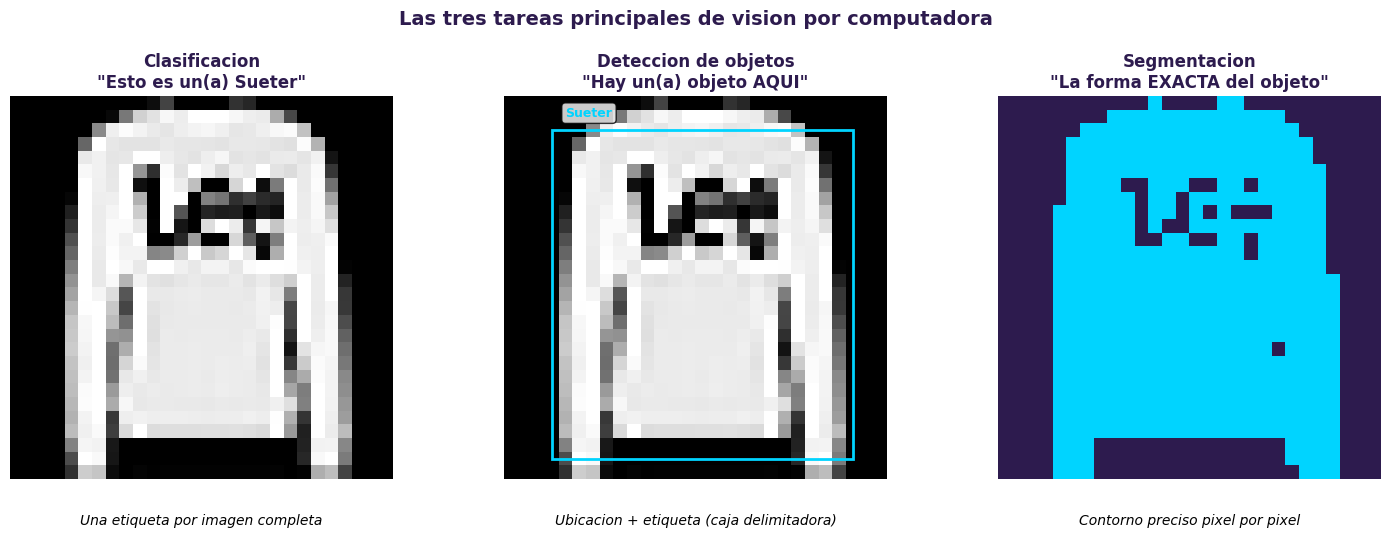

In [20]:
# Visualizacion conceptual: clasificacion vs deteccion vs segmentacion
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Imagen de ejemplo
img_demo = X_test[1]
cat_demo = nombres_categorias[y_test[1]]

# 1. Clasificacion
axes[0].imshow(img_demo, cmap='gray')
axes[0].set_title(f'Clasificacion\n"Esto es un(a) {cat_demo}"', fontsize=12, fontweight='bold', color=PURPLE)
axes[0].text(0.5, -0.12, 'Una etiqueta por imagen completa',
             transform=axes[0].transAxes, ha='center', fontsize=10, style='italic')
axes[0].axis('off')

# 2. Deteccion
axes[1].imshow(img_demo, cmap='gray')
import matplotlib.patches as patches
rect = patches.Rectangle((3, 2), 22, 24, linewidth=2, edgecolor=CYAN, facecolor='none')
axes[1].add_patch(rect)
axes[1].text(4, 1, f'{cat_demo}', fontsize=9, color=CYAN, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].set_title('Deteccion de objetos\n"Hay un(a) objeto AQUI"', fontsize=12, fontweight='bold', color=PURPLE)
axes[1].text(0.5, -0.12, 'Ubicacion + etiqueta (caja delimitadora)',
             transform=axes[1].transAxes, ha='center', fontsize=10, style='italic')
axes[1].axis('off')

# 3. Segmentacion
# Crear una mascara simple basada en umbral
mascara = img_demo > 30
img_segmentada = np.zeros((*img_demo.shape, 3), dtype=np.uint8)
img_segmentada[mascara] = [0, 212, 255]  # CYAN
img_segmentada[~mascara] = [45, 27, 78]  # PURPLE oscuro
axes[2].imshow(img_segmentada)
axes[2].set_title('Segmentacion\n"La forma EXACTA del objeto"', fontsize=12, fontweight='bold', color=PURPLE)
axes[2].text(0.5, -0.12, 'Contorno preciso pixel por pixel',
             transform=axes[2].transAxes, ha='center', fontsize=10, style='italic')
axes[2].axis('off')

plt.suptitle('Las tres tareas principales de vision por computadora',
             fontsize=14, fontweight='bold', color=PURPLE, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Aplicaciones empresariales reales (2025-2026)

Las CNNs ya no son tecnologia experimental. Son **infraestructura invisible** que sostiene industrias enteras.

### Manufactura y control de calidad
- La inspeccion visual humana detecta ~80% de defectos; la IA detecta **98%+**
- Cognex envio mas de 500,000 sistemas de vision 3D en 2025
- Periodo de retorno de inversion tipico: **6 a 12 meses**
- Keyence redujo falsos positivos de 8% a menos de 2% en estampado automotriz, ahorrando $1.2 millones anuales

### Salud y diagnostico medico
- La FDA ha aprobado mas de **1,000 dispositivos medicos con IA/ML**; 295 solo en 2025
- El 76% de las aprobaciones son en radiologia, y **todas** usan CNNs convencionales
- Philips SmartSpeed: resonancias magneticas cerebrales en menos de 10 segundos (3x mas rapido)
- La mamografia asistida por IA ha reducido los falsos negativos en un 20%

### Vehiculos autonomos
- Waymo completo **450,000 viajes pagados por semana** a finales de 2025
- Meta: 1 millon de viajes semanales en 2026 con expansion a 20+ ciudades
- Tesla FSD v13 opera en 47 estados de EE.UU.

### Agricultura
- John Deere (See & Spray): reduccion del **80-90%** en uso de herbicidas
- Drones con CNNs detectan enfermedades y deficiencias nutricionales antes de que sean visibles
- Mercado de IA en agricultura proyectado a $61.3 mil millones para 2035

### Retail
- ROI promedio de **374% en tres anos** (Forrester)
- Incrementos de ventas del 3-5% con video analitica
- Reduccion de merma del 15-30%

### En Costa Rica
- **Ainnova Tech** (San Jose): usa CNNs para detectar retinopatia diabetica y glaucoma. Alianza con Roche (dic. 2024), Forbes la nombro entre las 30 empresas mas prometedoras de America Latina
- **ENIA 2024-2027**: primera estrategia nacional de IA en Centroamerica
- El 75% de las multinacionales de servicios en Costa Rica implementan tecnologias basadas en IA
- Proyecto FEIMA (UCR): drones e IA para conteo de pinas y clasificacion de cultivos

---
## 10. Herramientas interactivas para seguir explorando (sin programar)

Si desean explorar CNNs de forma visual e interactiva, las siguientes herramientas son excelentes y no requieren conocimientos de programacion:

| Herramienta | Enlace | Para que sirve |
|-------------|--------|----------------|
| **CNN Explainer** | [poloclub.github.io/cnn-explainer](https://poloclub.github.io/cnn-explainer/) | Subir imagenes y ver como una CNN las procesa capa por capa con animaciones |
| **Google Teachable Machine** | [teachablemachine.withgoogle.com](https://teachablemachine.withgoogle.com/) | Construir un clasificador de imagenes usando su webcam, sin codigo |
| **CNN Playground** | [cnn-playground.live](https://cnn-playground.live/) | Subir cualquier foto para clasificacion con mapas de calor GradCAM |
| **CNN 3D de Adam Harley** | [adamharley.com/nn_vis/cnn/3d.html](https://adamharley.com/nn_vis/cnn/3d.html) | Dibujar digitos y ver activaciones 3D en tiempo real |
| **TensorFlow Playground** | [playground.tensorflow.org](https://playground.tensorflow.org/) | Experimentar con neuronas, capas y tasas de aprendizaje |

**Recomendacion para la clase:** Abran **CNN Explainer** y suban diferentes imagenes para ver como cambian las activaciones en cada capa. Es la mejor forma de consolidar lo que aprendimos hoy.

---
## 11. Resumen de conceptos clave

| Concepto | Definicion | Importancia para negocios |
|----------|-----------|---------------------------|
| **Convolucion** | Operacion que desliza filtros sobre una imagen para detectar patrones | Permite extraer informacion util de imagenes automaticamente |
| **Filtro/Kernel** | Pequena matriz de numeros que detecta un patron especifico | La CNN aprende los filtros optimos a partir de datos (no requiere expertos) |
| **Mapa de caracteristicas** | Resultado de aplicar un filtro a la imagen | Muestra donde se encontro un patron (util para explicabilidad) |
| **Pooling** | Reduccion del tamano de los mapas de caracteristicas | Hace el modelo mas eficiente y robusto a variaciones |
| **Fully connected** | Capas que combinan todas las caracteristicas para decidir | El "comite directivo" que toma la decision final |
| **Transfer learning** | Reutilizar una CNN pre-entrenada para un nuevo problema | Reduce drasticamente el costo y tiempo de desarrollo |
| **Clasificacion** | Asignar una etiqueta a una imagen completa | Catalogacion automatica de productos, diagnostico medico |
| **Deteccion de objetos** | Localizar y etiquetar multiples objetos en una imagen | Conteo de inventario, monitoreo de seguridad, conduccion autonoma |
| **Segmentacion** | Delimitar la forma exacta de cada objeto, pixel por pixel | Control de calidad de alta precision, imagenes medicas |

---
## Siguiente paso: Caso 10

Ahora que entienden como funcionan las CNNs y donde se aplican, es momento de aplicar estos conocimientos al **Caso 10: CafeVision** -- un caso de control de calidad de cafe en Costa Rica usando vision por computadora.

En equipos, analizaran si CoopeTarrazu deberia invertir $250,000 en un sistema de clasificacion de granos de cafe basado en CNNs. Consideraran la viabilidad financiera, la comunicacion con stakeholders, la estrategia de implementacion y las implicaciones eticas.

Los conceptos de este notebook seran su base tecnica para fundamentar sus decisiones.